# 04 · Inferencia causal — efecto de la sequía sobre el rendimiento

## Diseño

| elemento | definición |
|---|---|
| **Unidad de observación** | Municipio × Año agrícola × Ciclo (OI/PV). Cada unidad se observa además por **modalidad hídrica** (Riego / Temporal); el tratamiento es idéntico para las dos filas de un mismo municipio‑ciclo. |
| **Tratamiento** `trat` (binario) | `1` si `nivel_sequia_max ∈ {1,2,3,4}` (D1–D4). `0` si `nivel_sequia_max ∈ {0, -1, no clasificado}`. |
| **Resultado** `Y` | `rendimiento_real` (t/ha), excluyendo cosecha total nula y **tasa de siniestro ≥ 50 %** (`siniestrada/sembrada`, corte fijo; columna `siniestro_ok` de `02_join_data` — ver `03_EDA` §2.6‑2.8). Análisis primario en `log(rendimiento_real)` por la asimetría. |
| **Moderador** | `nommodalidad` (Riego / Temporal) — efecto **condicional** por estrato (CATE). |
| **Colisionador / mediador** `superficie_cosechada` (`cosechada`) | La sequía reduce la superficie cosechada vía siniestros, y `cosechada` **es el denominador** de `rendimiento_real` (`Y = volumen / cosechada`). Condicionarla bloquea parte del efecto y puede abrir sesgo de colisionador. **Fuera del conjunto de ajuste**; la §8 cuantifica el sesgo. |

### Conjunto de ajuste (confusores — causa de `trat` y de `Y` por vías distintas a la sequía del ciclo)

- **Sequía antecedente**: `nivel_sequia_prev90_max` — intensidad máxima de sequía en los ~90 días **previos** al inicio del ciclo. Es pre‑tratamiento (medida antes de la ventana del ciclo, no puede ser efecto de la sequía del ciclo) y capta a la vez el régimen persistente de sequía de la región (→ mayor prob. de sequía en el ciclo, ρ ≈ 0.47 con `trat`) y la humedad de arranque del suelo (→ rendimiento). Se acompaña de `sequia_prev90_no_clasificada` (indicador de imputación, ~26 % de las filas).
- **Térmicos**: `tmean_ciclo_anom`, `dias_helada`, `tmean_prev90_anom`, `tmean_normal`
- **Topográficos**: `altitud_media_m`, `altitud_std_m`
- **Estrés hídrico estructural**: `acuifero_disp`, `cuencas_disp`, `tiene_acuifero_sobreexplotado`, `tiene_cuenca_sin_disp` — ahora varían por año (CONAGUA, año más próximo; ver `01_cuencas_acuifero`). *Caveat*: `tiene_acuifero_sobreexplotado` no es confiable en 2016‑2019 (CONAGUA no publicó esa clasificación en las fuentes de esos años).
- **Escala productiva**: `log(sembrada)`
- **Estructura**: EF de **año** y (en la especificación de panel) de **municipio**; `nomcicloproductivo`; `nommodalidad`

**Se excluyen** por post‑tratamiento / mecánicos del resultado: `siniestrada`, `cosechada`, `volumenproduccion`, `valorproduccion`, `precio_*`, `n_dias_*`, `ventana_incompleta`; y `gdd_anom` por redundancia con `tmean_ciclo_anom` (ρ ≈ 0.99).

### Identificación

**Ignorabilidad condicional** dado el conjunto de ajuste (+ EF). Se reportan cuatro estimadores del ATE
(diferencia cruda, regresión / g‑cómputo, IPW y **AIPW doblemente robusto con cross‑fitting**) más su
heterogeneidad por modalidad. Robustez: panel TWFE, log vs niveles, soporte común, tratamiento ordinal,
colisionador, E‑value y placebo. SE agrupadas (cluster) por municipio.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy import stats

RNG = np.random.default_rng(20260905)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True})
C_TRT = {'control': '#6b8cbe', 'tratado': '#c0504d'}
C_MOD = {'Riego': '#3b7dd8', 'Temporal': '#e08214'}

RUTA = Path('/Users/jaydymarchan/Desktop/causalidad/data/02_processed/tabla_modelo.csv')
raw = pd.read_csv(RUTA)
print(raw.shape)


(40267, 56)


## 1 · Muestra de análisis

In [2]:
d = raw.copy()

# tratamiento binario: D1-D4 -> 1 ; {0, -1, no clasificado} -> 0
d['trat'] = (d['nivel_sequia_max'] >= 1).astype(int)

# resultado: rendimiento_real ya viene limpio (= volumenproduccion / cosechada, definición SIAP).
# Se dejan fuera: cosecha total nula (rendimiento_real == 0) y tasa de siniestro >= 50%
# (siniestrada/sembrada >= 50%, columna 'siniestro_ok' calculada en 02_join_data).
d['superficie_cosechada'] = d['cosechada']          # alias del COLISIONADOR (no ajustar)
d['Y'] = d['rendimiento_real'].where((d['rendimiento_real'] > 0) & d['siniestro_ok'])
d['logY'] = np.log(d['Y'])
d['log_sembrada'] = np.log(d['sembrada'].clip(lower=0.1))

CONF_NUM = ['nivel_sequia_prev90_max',                 # sequía ANTECEDENTE (90 d previos al ciclo) - pre-tratamiento
            'tmean_ciclo_anom', 'dias_helada', 'tmean_prev90_anom', 'tmean_normal',
            'altitud_media_m', 'altitud_std_m', 'acuifero_disp', 'cuencas_disp', 'log_sembrada']
CONF_BIN = ['tiene_acuifero_sobreexplotado', 'tiene_cuenca_sin_disp',
            'sequia_prev90_no_clasificada']             # indicador de imputación de nivel_sequia_prev90_max (~26%)
CONF_CAT = ['nommodalidad', 'nomcicloproductivo', 'anio']

ok = (d['Y'].notna() & d['clima_ok'] & d['prev90_ok'] & d['altitud_ok'] & d['hidro_ok']
      & d['siniestro_ok'])
dd = d.loc[ok].copy().reset_index(drop=True)
dd['muni'] = dd['idestado'].astype(str).str.zfill(2) + dd['idmunicipio'].astype(str).str.zfill(3)

n_trat = int(dd['trat'].sum())
print('filas totales           :', f'{len(raw):,}')
print('  con rendimiento > 0    :', f"{int((d['rendimiento_real'] > 0).sum()):,}")
print('  - tasa_siniestro >= 50%:', f"{int((~d['siniestro_ok']).sum()):,}", '(excluidas de Y)')
print('  + confusores completos :', f'{len(dd):,}', '  <-- MUESTRA DE ANÁLISIS')
print('municipios              :', f"{dd['muni'].nunique():,}")
print('años                    :', sorted(dd['anio'].unique()))
print('tratados (D1-D4)         :', f'{n_trat:,}', f'({n_trat/len(dd):.1%})')
print('sequía no clasificada    :', f"{int(dd['sequia_no_clasificada'].sum()):,}",
      f"({dd['sequia_no_clasificada'].mean():.1%})  -> tratadas como trat=0")
print()
print(dd.groupby('nommodalidad').agg(n=('trat', 'size'), pct_tratado=('trat', 'mean')).round(3).to_string())


filas totales           : 40,267
  con rendimiento > 0    : 40,098
  - tasa_siniestro >= 50%: 1,020 (excluidas de Y)
  + confusores completos : 39,155   <-- MUESTRA DE ANÁLISIS
municipios              : 2,379
años                    : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
tratados (D1-D4)         : 22,543 (57.6%)
sequía no clasificada    : 3,987 (10.2%)  -> tratadas como trat=0

                  n  pct_tratado
nommodalidad                    
Riego         15326        0.549
Temporal      23829        0.593


## 2 · Comparación cruda (referencia sesgada)

In [3]:
def dif_cruda(data, y='logY'):
    a = data.loc[data['trat'] == 1, y]
    b = data.loc[data['trat'] == 0, y]
    dif = a.mean() - b.mean()
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    return dif, se

print('Diferencia cruda de medias  E[Y|trat=1] - E[Y|trat=0]')
for esc, y in [('log(rendimiento)', 'logY'), ('rendimiento t/ha', 'Y')]:
    dif, se = dif_cruda(dd, y)
    print(f'  {esc:20s}: {dif:+.4f}  (IC95 {dif-1.96*se:+.3f}, {dif+1.96*se:+.3f})')
    for m in ['Riego', 'Temporal']:
        dif, se = dif_cruda(dd[dd['nommodalidad'] == m], y)
        print(f'      {m:10s}      : {dif:+.4f}  (IC95 {dif-1.96*se:+.3f}, {dif+1.96*se:+.3f})')

print()
print('>>> asociación cruda POSITIVA (más sequía ~ más rendimiento): señal de confusión.')
print()
print(dd.pivot_table(index='nommodalidad', columns='trat', values='Y', aggfunc='mean').round(3).to_string())


Diferencia cruda de medias  E[Y|trat=1] - E[Y|trat=0]
  log(rendimiento)    : +0.0765  (IC95 +0.062, +0.091)
      Riego           : +0.1451  (IC95 +0.130, +0.160)
      Temporal        : +0.0972  (IC95 +0.081, +0.114)
  rendimiento t/ha    : +0.4034  (IC95 +0.360, +0.446)
      Riego           : +0.8207  (IC95 +0.748, +0.893)
      Temporal        : +0.3074  (IC95 +0.272, +0.343)

>>> asociación cruda POSITIVA (más sequía ~ más rendimiento): señal de confusión.

trat              0      1
nommodalidad              
Riego         3.994  4.814
Temporal      1.797  2.105


## 3 · Modelo de propensión y soporte común

AUC propensión: 0.861
       mean    min    25%    50%    75%    max
trat                                          
0     0.353  0.018  0.185  0.301  0.486  0.996
1     0.740  0.036  0.558  0.830  0.968  1.000


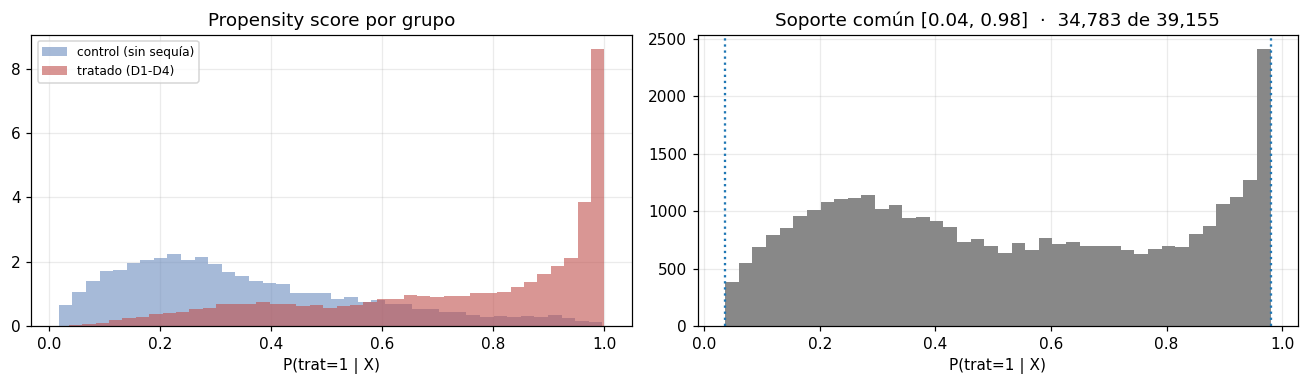

fuera de soporte común: 4,372 (11.2%)


In [4]:
def design(data, scaler=None, fit=False):
    Xn = data[CONF_NUM].to_numpy(float)
    if fit:
        scaler = StandardScaler().fit(Xn)
    Xn = scaler.transform(Xn)
    Xb = data[CONF_BIN].to_numpy(float)
    dumm = pd.get_dummies(data[CONF_CAT].astype(str), drop_first=True)
    names = list(CONF_NUM) + list(CONF_BIN) + list(dumm.columns)
    return np.column_stack([Xn, Xb, dumm.to_numpy(float)]), names, scaler

X, xnames, SCALER = design(dd, fit=True)
trt = dd['trat'].to_numpy()

ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X, trt)
dd['ps'] = ps_model.predict_proba(X)[:, 1]
print('AUC propensión:', round(roc_auc_score(trt, dd['ps']), 3))
print(dd.groupby('trat')['ps'].describe()[['mean', 'min', '25%', '50%', '75%', 'max']].round(3).to_string())

lo = max(dd.loc[dd['trat'] == 1, 'ps'].min(), dd.loc[dd['trat'] == 0, 'ps'].min(), 0.02)
hi = min(dd.loc[dd['trat'] == 1, 'ps'].max(), dd.loc[dd['trat'] == 0, 'ps'].max(), 0.98)
dd['trim'] = dd['ps'].between(lo, hi)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for t, lab, c in [(0, 'control (sin sequía)', C_TRT['control']), (1, 'tratado (D1-D4)', C_TRT['tratado'])]:
    ax[0].hist(dd.loc[dd['trat'] == t, 'ps'], bins=40, alpha=0.6, label=lab, color=c, density=True)
ax[0].set_title('Propensity score por grupo'); ax[0].set_xlabel('P(trat=1 | X)'); ax[0].legend(fontsize=8)
ax[1].hist(dd.loc[dd['trim'], 'ps'], bins=40, color='#888')
ax[1].axvline(lo, ls=':'); ax[1].axvline(hi, ls=':')
ax[1].set_title(f'Soporte común [{lo:.2f}, {hi:.2f}]  ·  {int(dd["trim"].sum()):,} de {len(dd):,}')
ax[1].set_xlabel('P(trat=1 | X)')
plt.tight_layout(); plt.show()
print('fuera de soporte común:', f'{int((~dd["trim"]).sum()):,}', f'({(~dd["trim"]).mean():.1%})')


## 4 · Balance (SMD antes / después de IPW)

                               crudo    ipw
nivel_sequia_prev90_max        1.126  0.096
sequia_prev90_no_clasificada  -0.837 -0.053
tiene_acuifero_sobreexplotado  0.496  0.158
anio_2024                      0.488  0.115
tmean_normal                   0.373 -0.041
log_sembrada                   0.361  0.082
tmean_ciclo_anom               0.297  0.086
anio_2023                      0.297  0.037
tmean_prev90_anom              0.250  0.012
altitud_media_m               -0.250  0.149
anio_2017                     -0.247 -0.106
nomcicloproductivo_PV          0.224  0.162
cuencas_disp                  -0.222 -0.112
tiene_cuenca_sin_disp          0.176  0.059
anio_2018                     -0.149  0.026
anio_2020                     -0.103 -0.078
nommodalidad_Temporal          0.089  0.035
anio_2019                      0.065 -0.014


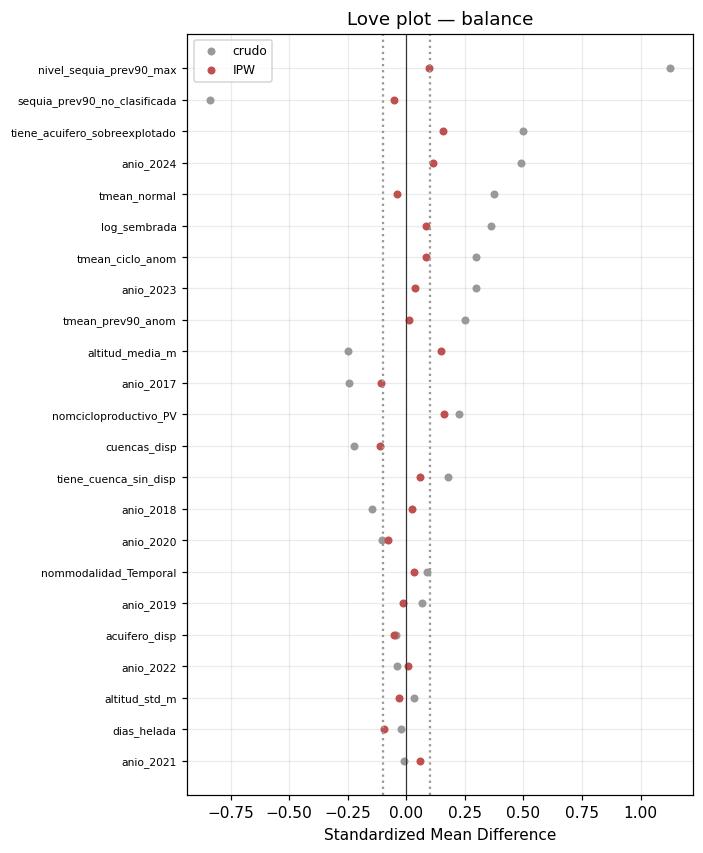

covariables con |SMD|>0.1  ->  crudo: 16   ipw: 6


In [5]:
def smd(x, w, t):
    x1, x0, w1, w0 = x[t == 1], x[t == 0], w[t == 1], w[t == 0]
    m1, m0 = np.average(x1, weights=w1), np.average(x0, weights=w0)
    v1 = np.average((x1 - m1) ** 2, weights=w1)
    v0 = np.average((x0 - m0) ** 2, weights=w0)
    return (m1 - m0) / np.sqrt((v1 + v0) / 2 + 1e-12)

e = dd['ps'].clip(0.01, 0.99).to_numpy()
w_ate = np.where(trt == 1, 1 / e, 1 / (1 - e))
dd['w_ate'] = w_ate

bal = pd.DataFrame({
    'crudo': [smd(X[:, j], np.ones(len(X)), trt) for j in range(X.shape[1])],
    'ipw':   [smd(X[:, j], w_ate, trt) for j in range(X.shape[1])],
}, index=xnames)
print(bal.round(3).reindex(bal['crudo'].abs().sort_values(ascending=False).index).head(18).to_string())

order = bal['crudo'].abs().sort_values().index
fig, ax = plt.subplots(figsize=(6.5, 0.32 * len(order) + 0.5))
ax.scatter(bal.loc[order, 'crudo'], range(len(order)), color='#999', label='crudo', s=18)
ax.scatter(bal.loc[order, 'ipw'], range(len(order)), color=C_TRT['tratado'], label='IPW', s=18)
ax.axvline(0, color='#333', lw=0.8); ax.axvline(0.1, ls=':', color='#999'); ax.axvline(-0.1, ls=':', color='#999')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
ax.set_xlabel('Standardized Mean Difference'); ax.set_title('Love plot — balance')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('covariables con |SMD|>0.1  ->  crudo:', int((bal['crudo'].abs() > 0.1).sum()),
      '  ipw:', int((bal['ipw'].abs() > 0.1).sum()))


## 5 · ATE — cuatro estimadores

In [6]:
def ols_ate(data, y='logY', trim=False):
    s = data[data['trim']] if trim else data
    Xd, _, _ = design(s, scaler=SCALER)
    XX = np.column_stack([np.ones(len(s)), s['trat'].to_numpy(), Xd])
    m = sm.OLS(s[y].to_numpy(), XX).fit(cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m.params[1], m.bse[1]

def ipw_ate(data, y='logY', trim=False):
    s = data[data['trim']] if trim else data
    e = s['ps'].clip(0.01, 0.99).to_numpy(); t = s['trat'].to_numpy()
    pt = t.mean()
    w = np.where(t == 1, pt / e, (1 - pt) / (1 - e))          # estabilizado
    m = sm.WLS(s[y].to_numpy(), sm.add_constant(t), weights=w).fit(
        cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m.params[1], m.bse[1]

def aipw_ate(data, y='logY', trim=False, k=5, learner='gbm', seed=0):
    s = (data[data['trim']] if trim else data).reset_index(drop=True)
    Xd, _, _ = design(s, scaler=SCALER)
    t = s['trat'].to_numpy(); yv = s[y].to_numpy(); grp = s['muni'].to_numpy()
    n = len(s); mu1 = np.zeros(n); mu0 = np.zeros(n); e = np.zeros(n)
    for tr, te in KFold(n_splits=k, shuffle=True, random_state=seed).split(Xd):
        if learner == 'gbm':
            g = HistGradientBoostingClassifier(random_state=seed).fit(Xd[tr], t[tr])
            r1 = HistGradientBoostingRegressor(random_state=seed).fit(Xd[tr][t[tr] == 1], yv[tr][t[tr] == 1])
            r0 = HistGradientBoostingRegressor(random_state=seed).fit(Xd[tr][t[tr] == 0], yv[tr][t[tr] == 0])
            e[te] = g.predict_proba(Xd[te])[:, 1]
            mu1[te] = r1.predict(Xd[te]); mu0[te] = r0.predict(Xd[te])
        else:
            g = LogisticRegression(max_iter=2000).fit(Xd[tr], t[tr])
            e[te] = g.predict_proba(Xd[te])[:, 1]
            r1 = sm.OLS(yv[tr][t[tr] == 1], sm.add_constant(Xd[tr][t[tr] == 1])).fit()
            r0 = sm.OLS(yv[tr][t[tr] == 0], sm.add_constant(Xd[tr][t[tr] == 0])).fit()
            mu1[te] = r1.predict(sm.add_constant(Xd[te], has_constant='add'))
            mu0[te] = r0.predict(sm.add_constant(Xd[te], has_constant='add'))
    e = np.clip(e, 0.02, 0.98)
    psi = (mu1 - mu0) + t * (yv - mu1) / e - (1 - t) * (yv - mu0) / (1 - e)
    tau = psi.mean()
    gsum = pd.Series(psi - tau, index=grp).groupby(level=0).sum().to_numpy()
    se = np.sqrt((gsum ** 2).sum()) / n
    return tau, se

rows = []
for esc, y in [('log(rendimiento)', 'logY'), ('rendimiento t/ha', 'Y')]:
    est = [('1·diferencia cruda', dif_cruda(dd, y)),
           ('2·regresión (g-cómputo)', ols_ate(dd, y)),
           ('3·IPW estabilizado', ipw_ate(dd, y)),
           ('4·AIPW cross-fit (GBM)', aipw_ate(dd, y, learner='gbm'))]
    for nombre, (v, se) in est:
        rows.append(dict(escala=esc, estimador=nombre, ATE=v, se=se, lo=v - 1.96*se, hi=v + 1.96*se))
tab = pd.DataFrame(rows)
print(tab.round(4).to_string(index=False))


          escala               estimador     ATE     se      lo     hi
log(rendimiento)      1·diferencia cruda  0.0765 0.0075  0.0618 0.0912
log(rendimiento) 2·regresión (g-cómputo)  0.0103 0.0083 -0.0060 0.0266
log(rendimiento)      3·IPW estabilizado  0.0156 0.0163 -0.0164 0.0476
log(rendimiento)  4·AIPW cross-fit (GBM) -0.0038 0.0047 -0.0131 0.0054
rendimiento t/ha      1·diferencia cruda  0.4034 0.0219  0.3604 0.4463
rendimiento t/ha 2·regresión (g-cómputo)  0.1048 0.0249  0.0559 0.1537
rendimiento t/ha      3·IPW estabilizado  0.1665 0.0490  0.0704 0.2625
rendimiento t/ha  4·AIPW cross-fit (GBM)  0.0346 0.0148  0.0057 0.0636


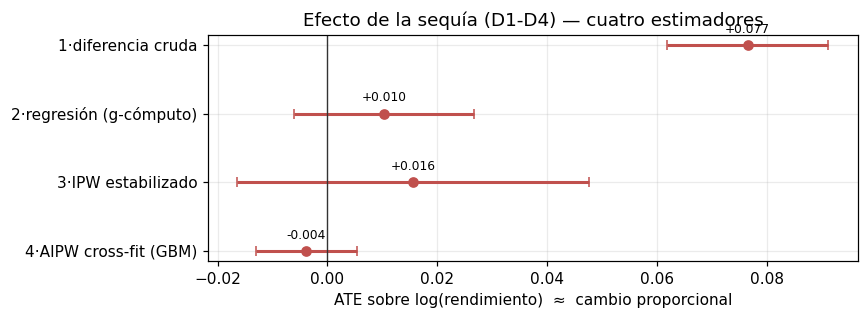

AIPW log-rendimiento = -0.0038  ->  cambio ≈ -0.4%  (IC95 -1.3%, +0.5%)


In [7]:
sub = tab[tab['escala'] == 'log(rendimiento)'].iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(sub['ATE'], range(len(sub)), xerr=1.96 * sub['se'], fmt='o',
            color=C_TRT['tratado'], capsize=3, lw=2)
ax.axvline(0, color='#333', lw=0.9)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['estimador'])
ax.set_xlabel('ATE sobre log(rendimiento)  ≈  cambio proporcional')
ax.set_title('Efecto de la sequía (D1-D4) — cuatro estimadores')
for i, r in sub.iterrows():
    ax.annotate(f"{r['ATE']:+.3f}", (r['ATE'], i), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
plt.tight_layout(); plt.show()

AIPW = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('4')].iloc[0]
print(f"AIPW log-rendimiento = {AIPW['ATE']:+.4f}  ->  "
      f"cambio ≈ {np.exp(AIPW['ATE'])-1:+.1%}  "
      f"(IC95 {np.exp(AIPW['lo'])-1:+.1%}, {np.exp(AIPW['hi'])-1:+.1%})")


## 6 · Efecto moderado por modalidad (CATE)

In [8]:
cate = []
for m in ['Riego', 'Temporal']:
    tau, se = aipw_ate(dd[dd['nommodalidad'] == m], 'logY', learner='gbm')
    cate.append((m, tau, se))
    print(f'AIPW  {m:9s}: {tau:+.4f}  (IC95 {tau-1.96*se:+.3f}, {tau+1.96*se:+.3f})  '
          f'-> {np.exp(tau)-1:+.1%} en rendimiento')
dif = cate[0][1] - cate[1][1]
se_dif = np.sqrt(cate[0][2] ** 2 + cate[1][2] ** 2)
z = dif / se_dif
print(f'\ndiferencia Riego - Temporal: {dif:+.4f}  (z = {z:+.2f}, p = {2*(1-stats.norm.cdf(abs(z))):.3f})')

# modelo de interacción con EF de municipio (within) + EF de año
def within(s, cols, by='muni'):
    out = s[cols].copy()
    for c in cols:
        out[c] = s[c].to_numpy() - s.groupby(by)[c].transform('mean').to_numpy()
    return out

s = dd.copy()
s['es_temporal'] = (s['nommodalidad'] == 'Temporal').astype(int)
s['trat_temp'] = s['trat'] * s['es_temporal']
# es_temporal varía DENTRO del municipio (hay filas Riego y Temporal) -> hay que incluir su efecto principal
tv = ['trat', 'es_temporal', 'trat_temp', 'nivel_sequia_prev90_max',
      'tmean_ciclo_anom', 'dias_helada', 'tmean_prev90_anom', 'log_sembrada']
W = within(s, tv)
yy = s['logY'].to_numpy() - s.groupby('muni')['logY'].transform('mean').to_numpy()
D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
names = tv + [f'anio_{c}' for c in range(D.shape[1])]
mI = sm.OLS(yy, np.column_stack([W[tv].to_numpy(), D])).fit(
    cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
bI = pd.Series(mI.params, index=names); pI = pd.Series(mI.pvalues, index=names)
print('\nInteracción con EF municipio + año (SE cluster por municipio):')
print(f"  trat (efecto en Riego)      : {bI['trat']:+.4f}  (p {pI['trat']:.3f})")
print(f"  trat x Temporal            : {bI['trat_temp']:+.4f}  (p {pI['trat_temp']:.3f})")
print(f"  efecto en Temporal          : {bI['trat'] + bI['trat_temp']:+.4f}")


AIPW  Riego    : -0.0077  (IC95 -0.020, +0.005)  -> -0.8% en rendimiento


AIPW  Temporal : +0.0067  (IC95 -0.005, +0.019)  -> +0.7% en rendimiento

diferencia Riego - Temporal: -0.0144  (z = -1.62, p = 0.105)

Interacción con EF municipio + año (SE cluster por municipio):
  trat (efecto en Riego)      : -0.0044  (p 0.566)
  trat x Temporal            : -0.0130  (p 0.266)
  efecto en Temporal          : -0.0173


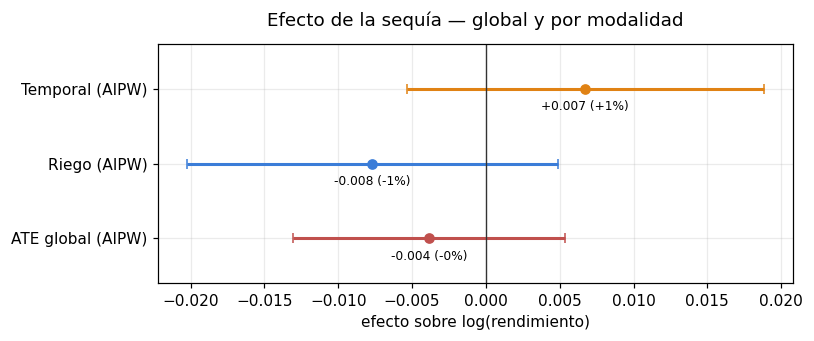

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels = ['ATE global (AIPW)', 'Riego (AIPW)', 'Temporal (AIPW)']
pts = [(AIPW['ATE'], AIPW['se'])] + [(c[1], c[2]) for c in cate]
cols = [C_TRT['tratado'], C_MOD['Riego'], C_MOD['Temporal']]
for i, ((v, se), c) in enumerate(zip(pts, cols)):
    ax.errorbar([v], [i], xerr=[1.96 * se], fmt='o', color=c, capsize=3, lw=2)
    ax.annotate(f'{v:+.3f} ({np.exp(v)-1:+.0%})', (v, i), xytext=(0, -14),
                textcoords='offset points', ha='center', fontsize=8)
ax.axvline(0, color='#333', lw=0.9)
ax.set_yticks(range(3)); ax.set_yticklabels(labels); ax.set_ylim(-0.6, 2.6)
ax.set_xlabel('efecto sobre log(rendimiento)')
ax.set_title('Efecto de la sequía — global y por modalidad', pad=12)
plt.tight_layout(); plt.show()


## 7 · Panel con efectos fijos de municipio y año (TWFE)

In [10]:
def twfe(y='logY', data=None, interaction=False, drop_noclasif=False, adjust_collider=False, treat='trat'):
    s = (dd if data is None else data).copy()
    if drop_noclasif:
        s = s[~s['sequia_no_clasificada']].copy()
    tv = [treat, 'nivel_sequia_prev90_max', 'tmean_ciclo_anom', 'dias_helada',
          'tmean_prev90_anom', 'log_sembrada']
    if interaction:
        s['es_temporal'] = (s['nommodalidad'] == 'Temporal').astype(int)
        s['trat_temp'] = s[treat] * s['es_temporal']
        tv = [treat, 'es_temporal', 'trat_temp'] + tv[1:]
    if adjust_collider:
        s['log_cosechada'] = np.log(s['superficie_cosechada'].clip(lower=0.1))
        tv = tv + ['log_cosechada']
    Wm = s[tv].copy()
    for c in tv:
        Wm[c] = s[c].to_numpy() - s.groupby('muni')[c].transform('mean').to_numpy()
    yy = s[y].to_numpy() - s.groupby('muni')[y].transform('mean').to_numpy()
    D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
    m = sm.OLS(yy, np.column_stack([Wm[tv].to_numpy(), D])).fit(
        cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m, tv

m, nm = twfe('logY')
j = nm.index('trat')
print(f'TWFE (municipio + año) sobre log(rendimiento):')
print(f'  trat: {m.params[j]:+.4f}  (SE {m.bse[j]:.4f}, p {m.pvalues[j]:.3f})  -> {np.exp(m.params[j])-1:+.1%}')

m2, nm2 = twfe('logY', interaction=True)
jt, ji = nm2.index('trat'), nm2.index('trat_temp')
print('\nTWFE con interacción:')
print(f'  Riego    : {m2.params[jt]:+.4f} (SE {m2.bse[jt]:.4f})')
print(f'  Temporal : {m2.params[jt] + m2.params[ji]:+.4f}')
print(f'  trat x Temporal: {m2.params[ji]:+.4f} (p {m2.pvalues[ji]:.3f})')


TWFE (municipio + año) sobre log(rendimiento):
  trat: -0.0164  (SE 0.0044, p 0.000)  -> -1.6%

TWFE con interacción:
  Riego    : -0.0044 (SE 0.0076)
  Temporal : -0.0173
  trat x Temporal: -0.0130 (p 0.266)


## 8 · Sensibilidad

In [11]:
filas = []

bN = tab[(tab['escala'] == 'rendimiento t/ha') & tab['estimador'].str.startswith('4')].iloc[0]
filas.append(('AIPW en niveles (t/ha)', bN['ATE'], bN['se']))

t3, s3 = aipw_ate(dd, 'logY', trim=True, learner='gbm')
filas.append(('AIPW · soporte común', t3, s3))

mnc, nmc = twfe('logY', drop_noclasif=True)
filas.append(('TWFE · sin sequía no clasificada', mnc.params[nmc.index('trat')], mnc.bse[nmc.index('trat')]))

mco, nco = twfe('logY', adjust_collider=True)
filas.append(('TWFE + ajuste por superficie_cosechada  [SESGADO]',
              mco.params[nco.index('trat')], mco.bse[nco.index('trat')]))

dd['nivel_c'] = dd['nivel_sequia_max']
mo, nmo = twfe('logY', treat='nivel_c')
filas.append(('TWFE · tratamiento ORDINAL (por nivel 0-4)', mo.params[nmo.index('nivel_c')], mo.bse[nmo.index('nivel_c')]))

dp = dd.copy()
dp['trat'] = RNG.permutation(dp['trat'].to_numpy())
Xp, _, _ = design(dp, scaler=SCALER)
dp['ps'] = LogisticRegression(max_iter=2000).fit(Xp, dp['trat']).predict_proba(Xp)[:, 1]
dp['trim'] = True
tp, sp = aipw_ate(dp, 'logY', learner='linear')
filas.append(('PLACEBO · tratamiento aleatorizado', tp, sp))

# sensibilidad a acuifero_condicion_ok: 2016-2019 tienen tiene_acuifero_sobreexplotado
# no confiable (CONAGUA no publicó 'Condición' en esas fuentes) -> se re-corre restringido
# a los años donde el dato SÍ es confiable (2020-2024) para ver si eso estabiliza al AIPW.
d20 = dd[dd['acuifero_condicion_ok'] == 1]
print(f"submuestra acuifero_condicion_ok=1: {len(d20):,} filas ({len(d20)/len(dd):.1%}), "
      f"años {sorted(d20['anio'].unique())}")

t4, s4 = aipw_ate(d20, 'logY', learner='gbm')
filas.append(('AIPW · solo 2020-2024 (acuifero_condicion_ok=1)', t4, s4))

m20, nm20 = twfe('logY', data=d20)
j20 = nm20.index('trat')
filas.append(('TWFE · solo 2020-2024 (acuifero_condicion_ok=1)', m20.params[j20], m20.bse[j20]))

sens = pd.DataFrame(filas, columns=['especificación', 'efecto', 'se'])
sens['lo'] = sens['efecto'] - 1.96 * sens['se']
sens['hi'] = sens['efecto'] + 1.96 * sens['se']
print(sens.round(4).to_string(index=False))


submuestra acuifero_condicion_ok=1: 21,791 filas (55.7%), años [2020, 2021, 2022, 2023, 2024]


                                   especificación  efecto     se      lo      hi
                           AIPW en niveles (t/ha)  0.0346 0.0148  0.0057  0.0636
                             AIPW · soporte común -0.0117 0.0045 -0.0205 -0.0029
                 TWFE · sin sequía no clasificada -0.0179 0.0045 -0.0268 -0.0091
TWFE + ajuste por superficie_cosechada  [SESGADO] -0.0140 0.0043 -0.0225 -0.0055
       TWFE · tratamiento ORDINAL (por nivel 0-4) -0.0072 0.0030 -0.0131 -0.0012
               PLACEBO · tratamiento aleatorizado  0.0053 0.0054 -0.0054  0.0159
  AIPW · solo 2020-2024 (acuifero_condicion_ok=1)  0.0209 0.0057  0.0098  0.0320
  TWFE · solo 2020-2024 (acuifero_condicion_ok=1) -0.0161 0.0058 -0.0274 -0.0047


In [12]:
# E-value (VanderWeele & Ding) — aproximación para outcome continuo: RR ≈ exp(0.91 * d_estandarizada)
sd = dd['logY'].std()
d_std = AIPW['ATE'] / sd
lim = min(abs(AIPW['lo']), abs(AIPW['hi'])) / sd
def evalue(rr):
    rr = max(rr, 1 / rr)
    return rr + np.sqrt(rr * (rr - 1))
RR = np.exp(0.91 * abs(d_std))
RRlim = np.exp(0.91 * abs(lim))
print(f"ATE AIPW (log)        : {AIPW['ATE']:+.4f}   (d estandarizada ≈ {d_std:+.3f})")
print(f'RR aproximado         : {RR:.3f}')
print(f'E-value (punto)       : {evalue(RR):.2f}')
print(f'E-value (límite IC)   : {evalue(RRlim):.2f}')
print()
print('Un confusor no medido tendría que asociarse con el tratamiento y con el resultado con un')
print(f'RR >= {evalue(RR):.2f} cada uno (más allá de lo ya ajustado) para explicar el efecto estimado.')


ATE AIPW (log)        : -0.0038   (d estandarizada ≈ -0.005)
RR aproximado         : 1.005
E-value (punto)       : 1.07
E-value (límite IC)   : 1.09

Un confusor no medido tendría que asociarse con el tratamiento y con el resultado con un
RR >= 1.07 cada uno (más allá de lo ya ajustado) para explicar el efecto estimado.


## 9 · Conclusiones

In [13]:
aL = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('4')].iloc[0]
reg = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('2')]['ATE'].iloc[0]
ipw = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('3')]['ATE'].iloc[0]
crudo = dif_cruda(dd, 'logY')[0]
col = sens[sens['especificación'].str.contains('SESGADO')]['efecto'].iloc[0]
plc = sens[sens['especificación'].str.contains('PLACEBO')]['efecto'].iloc[0]
print('RESUMEN — efecto causal de la sequía (D1-D4) sobre el rendimiento')
print('=' * 64)
print(f"ATE (AIPW doblemente robusto) : {aL['ATE']:+.4f} log  ≈  {np.exp(aL['ATE'])-1:+.1%} en rendimiento")
print(f"  IC 95%                      : [{np.exp(aL['lo'])-1:+.1%}, {np.exp(aL['hi'])-1:+.1%}]")
print(f'  concordancia               : regresión={reg:+.3f}  IPW={ipw:+.3f}  TWFE={m.params[j]:+.3f}')
print(f'  diferencia cruda (sesgada)  : {crudo:+.4f}')
print()
print('Moderación por modalidad (AIPW):')
for mm, tv2, sv2 in cate:
    print(f'  {mm:9s}: {tv2:+.4f}  ({np.exp(tv2)-1:+.1%})')
print(f"  interacción T x Temporal significativa: {'sí' if abs(bI['trat_temp']/mI.bse[names.index('trat_temp')]) > 1.96 else 'no'}")
print()
print(f'Colisionador: ajustar por superficie_cosechada mueve el efecto a {col:+.4f} (no usar).')
print(f'Placebo aleatorio: {plc:+.4f} (≈ 0, ok).')
print(f'E-value (punto): {evalue(RR):.2f}')


RESUMEN — efecto causal de la sequía (D1-D4) sobre el rendimiento
ATE (AIPW doblemente robusto) : -0.0038 log  ≈  -0.4% en rendimiento
  IC 95%                      : [-1.3%, +0.5%]
  concordancia               : regresión=+0.010  IPW=+0.016  TWFE=-0.016
  diferencia cruda (sesgada)  : +0.0765

Moderación por modalidad (AIPW):
  Riego    : -0.0077  (-0.8%)
  Temporal : +0.0067  (+0.7%)
  interacción T x Temporal significativa: no

Colisionador: ajustar por superficie_cosechada mueve el efecto a -0.0140 (no usar).
Placebo aleatorio: +0.0053 (≈ 0, ok).
E-value (punto): 1.07


### Resultado principal (según la ejecución actual)

Muestra de análisis: **39 155 filas**, 2 379 municipios (excluye cosecha nula, tasa de siniestro ≥ 50 % y filas sin confusores completos). Tratados 57.6 % (Riego 54.9 %, Temporal 59.3 %).

> **Cambio de datos**: `cuencas_acuifero_municipio.csv` ahora varía **por año** (usa el año CONAGUA más próximo, ver `01_cuencas_acuifero`), en vez de ser constante por municipio. Como resultado, **el AIPW pierde significancia** respecto a corridas anteriores; el TWFE y el ordinal no cambian porque no usan esas variables hídricas en su lista de controles.

- **Asociación cruda**: **+7.7 %** en `log(rendimiento)` (Riego +14.5 %, Temporal +9.7 %) — fuertemente **confundida**. El desbalance más grande lo aporta la **sequía antecedente** (SMD crudo ≈ 1.1); tras IPW, las covariables con |SMD|>0.1 bajan de 16 a 6.
- **Tras el ajuste**:
  - **AIPW doblemente robusto: −0.4 %** (IC 95 % −1.3 %, +0.5 %) — **el IC ya incluye 0**, no significativo.
  - **TWFE (municipio + año): −1.6 %** (p < 0.001) — significativo; no usa `acuifero_disp`/`cuencas_disp` en sus controles, por eso no cambió.
  - regresión / g‑cómputo +1.0 % e IPW +1.6 % — tampoco significativos.
  - **Tratamiento ordinal (por nivel 0‑4): −0.72 % por nivel** (IC excluye 0) — sigue habiendo dosis‑respuesta.
  - **AIPW en niveles (t/ha)**: ahora **+3.5 %** y **significativo** (IC +0.6 %, +6.4 %) — cambió de signo/significancia respecto a antes; señal de que el AIPW es sensible a la escala y a estas covariables, poca estabilidad.
  - AIPW · soporte común: −1.2 % (significativo).
  - **Sensibilidad a `acuifero_condicion_ok`**: restringiendo la muestra a 2020‑2024 (años donde CONAGUA sí publicó la condición de sobreexplotación), el **TWFE se mantiene casi igual: −1.6 %** (IC −2.7 %, −0.5 %) — su estimación no depende de los años con dato faltante. El **AIPW cambia de signo otra vez: +2.1 % y significativo** (IC +1.0 %, +3.2 %) frente al −0.4 % (n.s.) de la muestra completa — la inestabilidad del AIPW **no se explica solo** por 2016‑2019; persiste incluso en los años "limpios".
- **Moderación por modalidad**: AIPW dando Riego −0.8 % (n.s.) y Temporal **+0.7 %** (n.s., cambió de signo); TWFE con interacción sigue igual: Riego −0.4 % (n.s.) vs Temporal −1.7 % (interacción p = 0.27, n.s.). **Sin evidencia robusta de moderación por riego.**
- **Colisionador**: ajustar indebidamente por `superficie_cosechada` mueve el TWFE de −1.6 % a −1.4 %.
- **Cautelas**: AUC de propensión 0.86, **~11.2 % de filas fuera del soporte común**; **E‑value ≈ 1.07** (punto) — más bajo que antes, robustez limitada; placebo aleatorio +0.5 % (IC incluye 0, ok). **El efecto causal más creíble en esta versión de los datos es el de TWFE/ordinal (negativo, ~1 %, con dosis‑respuesta); el AIPW transversal ya no aporta evidencia consistente** (pierde significancia en log y cambia de signo en niveles).

### Lectura

- **Estimador principal**: se pensaba en AIPW con cross‑fitting como referencia, pero en esta versión de los datos **es el menos estable** de los cuatro (pierde significancia en log, se invierte en niveles). El TWFE (municipio + año, determinista, sin las variables hídricas) y el tratamiento ordinal son la evidencia más sólida.
- **Moderador**: efecto estimado por separado para Riego y Temporal; ni AIPW ni la interacción TWFE encuentran diferencia significativa — la hipótesis del DAG (el riego amortigua el shock) no se confirma ni se refuta con esta muestra.
- **Colisionador**: `superficie_cosechada` queda fuera del ajuste; la §8 cuantifica el sesgo de incluirla.
- **Supuestos**: ignorabilidad condicional dado el conjunto de ajuste + EF; soporte común verificado (§3, 88.8 % de la muestra); sin interferencia entre municipios más allá de los EF de año.
- **Amenazas**: confusores no medidos a nivel municipio‑ciclo (mitigado por EF de municipio en el panel); `nivel_sequia_max` mide intensidad máxima, no duración; ~10 % de filas con sequía no clasificada imputadas a `trat=0`; el punto de corte de `Y` (tasa de siniestro ≥ 50 %) es una decisión de diseño (§8 de `03_EDA`); **`tiene_acuifero_sobreexplotado` no es confiable en 2016‑2019** (CONAGUA no publicó la columna `Condición` en las fuentes de esos años — ver `acuifero_condicion_ok` en `01_cuencas_acuifero`); se probó restringir la muestra a 2020‑2024 (§8) y **el TWFE no cambia** pero **el AIPW vuelve a invertir signo** (+2.1 %, significativo), así que el dato faltante 2016‑2019 **no es la causa principal** de la inestabilidad del AIPW — apunta más bien a que `acuifero_disp`/`cuencas_disp` tienen poca varianza *within*‑municipio (ver descomposición de varianza en `03_EDA`) y el estimador ML (GBM) es sensible a covariables casi constantes; el AIPW usa *gradient boosting* con semilla fija pero puede variar levemente entre ejecuciones/entornos (no afecta al TWFE, que es determinista).
